<div style="text-align: center;">
<h1 style="font-weight: bold; margin: 20px 0;">
CCI PISCO Training: Monitoring changing climate in the cryosphere with satellite-derived data
</div>

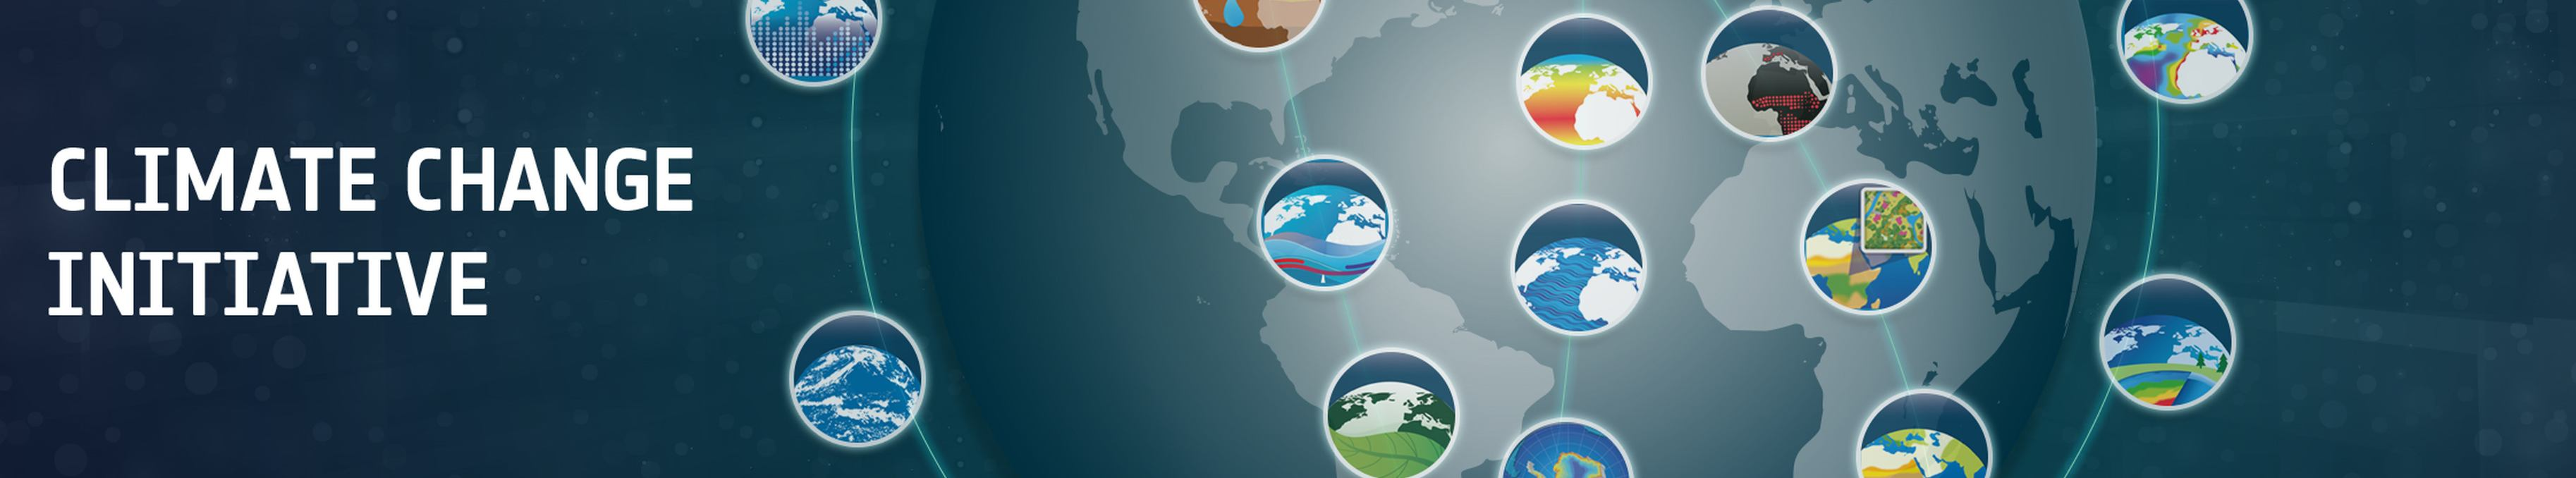

<div style="background-color: #96D7EB;  padding: 10px; border-left: 5px solid #96D7EB;">
<h2 style="margin: 0 0 15px 0; font-size: 1.4em;">Learning Objectives:</h2>


In this beginner-friendly notebook, we will use satellite-derived data from the [**ESA Climate Change Initiative (CCI)**](https://climate.esa.int/en/odp/#/dashboard) to explore how the climate is changing in the cryosphere.
For more information on how these datasets are produced, have a look at our Webinars Series **"Monitoring climate change from space"**: [**https://climate.esa.int/en/climate-change-initiative-training/webinars/**](https://climate.esa.int/en/climate-change-initiative-training/webinars/)


This notebook is designed for **participants with no prior experience in Python or climate data analysis**. 

You will learn:

1 - How to access and visualise ESA-CCI's Essential Climate Variables (ECVs)
* *What ECVs are available through the ESA-CCI data portal that are relevant to polar and cryosphere processes?*
* *How can you access this CCI ECVs and load it?*
* *How can you produce a first visualisation (e.g. a map or time series) to get familiar with the structure, resolution, and format of these datasets?*

2 - Analyse ESA-CCI's ECVs patterns to answer the following questions :
  
* *Has Sea Ice declined in the Arctic in the last years?*
* *Has the snow cover changed over the last decades, and how much?*

3 -  How uncertainty is represented and evaluated in CCI ECVs and how to work with these values in your own analyses

* *What uncertainty information is provided alongside CCI ECV products?*
* *How to propagate or visualise this uncertainty when computing derived quantities (such as trends, anomalies, spatial averages)?*
* *How does accounting for uncertainty change the confidence we can have in the trends identified?*

**Prerequisites:**
Basic Python familiarity and some experience with NumPy or pandas. 

No prior experience with satellite data is required.

**Estimated time:** ~2 hours

**🛠️ Tools We'll Use**

For this analysis we will rely on the [**ESA Climate Toolbox**](https://esa-climate-toolbox.readthedocs.io/en/latest/) which simplifies access, manipulation, and visualisation of CCI datasets in Python.

New to the toolbox? For a broader introduction to the toolbox and how to install it, visit:  

🔗 [**ESA CCI Climate Toolbox Quick Start**](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#jupyter-notebooks)  
🔗 [**ESA Climate Data Toolbox Website**](https://climate.esa.int/en/data/toolbox/)


The Toolbox package allows us to:

- Access satellite-based climate data records from ESA's Climate Change Initiative (CCI)
- Handle geospatial and temporal dimensions efficiently
- Aggregate and visualise climate data with intuitive plotting tools spatially and temporally

</div>

In [1]:
# ESA Climate Toolbox imports for accessing and plotting ESA CCI data
from esa_climate_toolbox.core import get_op              # Get predefined operations (e.g., time series, averages)
from esa_climate_toolbox.core import list_ecv_datasets   # List available datasets per ECV (Essential Climate Variable)
from esa_climate_toolbox.core import get_store           # Connect to an ESA data store
from esa_climate_toolbox.core import list_datasets       # List all datasets in a store
from esa_climate_toolbox.core import open_data           # Open datasets with the toolbox
from esa_climate_toolbox.ops import plot                 # High-level plotting functions for CCI data
from esa_climate_toolbox.ops import temporal_aggregation # Converting data into coarser time resolution based

# Used for connecting to remote data sources (e.g., ESA CCI ODP)
from xcube.core.store import new_data_store

# For displaying geographic regions interactively (if desired)
from IPython.display import GeoJSON
import shapely.geometry   # Handling geometric objects like bounding boxes
import folium

# Core data science libraries
import pandas as pd       # For tabular data handling and time manipulation
import numpy as np        # For numerical operations
import xarray as xr       # For multi-dimensional climate data structures

# Mapping and plotting
import matplotlib.pyplot as plt       # Plotting library
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs            # Cartographic projections for spatial data
import cartopy.feature as cfeature
import rasterio                       # Used to read GeoTIFF files
from datetime import datetime, timedelta

# Individual colormap creation
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.colors as mcolors

# Notebook settings
import warnings
warnings.filterwarnings("ignore") # Suppressing warnings to keep notebook output clean
%matplotlib inline

# used to transform to latitude and longitude
from pyproj import Transformer

You can execute the following cell to improve performance.

In [2]:
from dask.distributed import Client

client = Client(
    n_workers=2,
    threads_per_worker=16,
    processes=True,
    memory_limit="1.5GiB",
)

If you want to list all available ECVs, you can use the following commands:

In [3]:
# from esa_climate_toolbox.core import list_ecvs
# list_ecvs()

# 🛰️ CCI Snow
We will use the data products from the [**CCI Snow**](https://climate.esa.int/en/projects/snow/) project and look at the snow water equivalent (SWE). Details about the dataset can be found on the [project website](https://climate.esa.int/en/projects/snow/) and the provided [**Product User Guide**](https://climate.esa.int/media/documents/Snow_cci_D4.3_PUG_v5.1.pdf).  

With the command `list_ecv_datasets('Snow')`, we can call a list of all available CCI Snow datasets which can be loaded via the esa-climate-toolbox.

Before loading the data, we can inspect its structure and look at the attributes, data variables, dimensions, etc. by using the toolbox command `describe_data`.

In [4]:
# # list all datasets available from CCI Snow:
# list_ecv_datasets("Snow")

In [5]:
# We will use the zarr file as it is more efficient to load
cci_store = new_data_store('esa-cci-zarr')
snow_id = 'ESACCI-L3C_SNOW-SWE-1979-2020-fv2.0.zarr'
cci_store.describe_data(snow_id)

#### What do we learn from the details?

The datatype of the datafile we chose is "dataset" and we can directly access the data after loading it without additional steps. 

The `data_vars` show us which data variables are included. We are interested in the snow water equivalent `swe` and will therefore load this variable, by defining the `var_names` in the `open_data` command in the next cell. The unit of the snow water equivalent is *mm* which can be found when clicking on the `data_vars` → `swe` → `attrs`.

The attributes also tell us that there are flagged values. From the Product User Guide, we can learn what the code means: 
| Code  | Description                                               |
| ----- | --------------------------------------------------------- |
| 0     | Bare ground, no SWE retrieved (SWE = 0 mm)                |
| 1-500 | SWE (mm)                                                  |
| -1    | Masked: land areas for which no SWE retrieval attempted   |
| -10   | Masked: water (oceans, or water fraction > 50%)           |
| -20   | Masked: mountain                                          |
| -30   | Masked: Glaciers / permanent ice                          |

Since the ocean and areas with permanent ice are flagged, there is no data available those regions. Thus, we will later reduce the dataset to an area in North Europe where Snow data is available. 


Please note, that the dataset **only covers the Northern Hemisphere** as stated in the dataset summary as well as the Product User Guide. 

From the `time_range` we learn that dataset is available from 1979 - 2020 and the spatial resolution is 0.1°.

In [6]:
# defining which variables we would like to load
variables = ['swe','swe_std'] 

# using the open_data command from the toolbox to open the dataset
snow_ds, snow_name = open_data(snow_id, var_names = variables) 
# we can look at the dataset in Jupyter Notebook by simply writing the dataset name here; alternatively we could write display(snow_ds)
snow_ds

<xarray.Dataset> Size: 823GB
Dimensions:   (time: 7934, lat: 1800, lon: 3600, nv: 2)
Coordinates:
  * time      (time) datetime64[ns] 63kB 1979-01-02 1979-01-04 ... 2020-05-24
  * lat       (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon       (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9
    lat_bnds  (lat, nv) float64 29kB dask.array<chunksize=(900, 2), meta=np.ndarray>
    lon_bnds  (lon, nv) float64 58kB dask.array<chunksize=(900, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    swe       (time, lat, lon) float64 411GB dask.array<chunksize=(10, 900, 900), meta=np.ndarray>
    swe_std   (time, lat, lon) float64 411GB dask.array<chunksize=(10, 900, 900), meta=np.ndarray>
Attributes: (12/43)
    Conventions:                CF-1.9
    cdm_data_type:              grid
    comment:                    The following auxiliary datasets are used for...
    creator_email:              kari.luojus@fmi.fi (Scientific and Production...
    creator_name:               Finnish Meteorological Institute
    creator_url:                www.fmi.fi
    ...                         ...
    time_coverage_duration:     P1D
    time_coverage_end:          20200524T000000Z
    time_coverage_resolution:   P1D
    time_coverage_start:        19790102T000000Z
    title:                      ESA CCI snow SWE product level L3C daily, Dyn...
    tracking_id:                25063fb5-47ad-424a-8f26-29bdf35efb78

## Zooming In - Defining a Region of Interest
Let's reduce the data size by focussing on an area in Northern Europe.

To reduce the dataset spatially, we define a bounding box (bbox) for the desired area and apply the `subset_spatial`operation from the `esa-climate-toolbox` on our dataset. 

**Info**: Alternatively, the bounding box can already be applied when loading the data like this: 
`open_data(snow_id, var_names = variables, region = bbox)`

In [7]:
# Set bounding box by defining the longitude minimum, latitude minimum, longitude maximum and latitude maximum
bbox = (11, 66.5, 30, 71.5) 

# You can display the bounding box to check if the area is correct:
geom = shapely.geometry.box(*bbox)
centroid = geom.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=7)
folium.GeoJson(geom.__geo_interface__).add_to(m)
m

In [8]:
# Building the subset and saving it into a new dataset called snow_sub
subset_spatial_op = get_op('subset_spatial')
snow_sub = subset_spatial_op(ds = snow_ds, region = bbox)

Now let's plot a time in January of North Europe. 

We will use the `plot_map` function from the toolbox.

Since the data is flagged with values below 0, we can build our own colormap, e.g. add grey colour to the `Blues` colormap. If you want to reverse a colourmap, you can do so by adding a "_r" behind the name as shown in the next step.

In [9]:
# define the number of colours, this is usually 256, but we could also decrease the number and e.g. use 12
n = 256
# n = 12

# we will use the reversed Blues colormap, thus Blues_r
base = plt.get_cmap('Blues_r')(np.linspace(0, 1, n)) 
# adding grey colour, the last value represents the transparency given in "alpha" ranging from 0 to 1
grey = np.array([0.5, 0.5, 0.5, 0.1]) 

# adding grey to the colormap 
new_colors = np.vstack([grey, base])
# creating a colormap from the color list with matplotlib mcolors, so we can use it in the plots:
snow_cmap = mcolors.ListedColormap(new_colors)

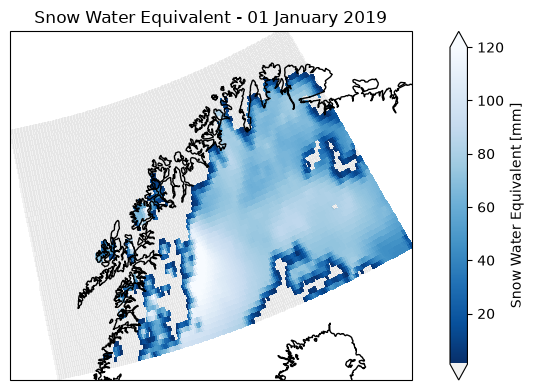

In [10]:
## now we define date we want to plot and retrieve the correct date for the title 
timestep = '2019-01-01'
# with the method = 'nearest', we assure that data close to what we defined as timestep will be used
time_str = snow_sub['time'].sel(time=timestep,method='nearest').dt.strftime('%d %B %Y').item()

# increasing the resolution of the figure 
plt.rcParams['figure.dpi'] = 100  

# getting the plotting operator from the toolbox
plot_map = get_op('plot_map')

ax = plot_map(
    snow_sub.sel(time=timestep, method='nearest'), 
    var="swe",
    projection="NorthPolarStereo", 
    title="Snow Water Equivalent - " + time_str,
    region=bbox,
    properties=dict(cmap=snow_cmap, 
                    vmin=1, vmax=120, # setting the boundaries of the colorbar, everything below 1 will therefore be shown as grey, since we use the self-defined snow_cmap
                   )
)
plt.gca().set_xlabel("Longitude")
plt.gca().set_ylabel("Latitude")
plt.show()

#### Calculating yearly means
In the next step, we will use the `temporal_aggregation` function from the esa_climate_toolbox to calculate the yearly means of the snow water equivalent, reducing the data volume and speeding up later processing.

First, we need to remove the flagged values to assure, we only take into account the actual snow water equivalent values for the mean. 

In [11]:
# get the temporal aggregation operator from the esa-climate-toolbox
from esa_climate_toolbox.ops import temporal_aggregation

# first, let's remove the coded values for mountains, glaciers and water and only use the positive values to calcualte the monthly mean:
snow_sub_clean = snow_sub.where(snow_sub.swe >= 0)

# now, we create monthly means using the cleaned dataset from above
snow_sub_y = temporal_aggregation(snow_sub_clean, 
                                method='mean', # here we can define what to do with the data, e.g. 'sum', 'mean', 'max'
                                period='Y') # 'M' = month, other inputs are e.g. 'Y' = year, 'QS-DEC' = quarterly 
display(snow_sub_y)

<xarray.Dataset> Size: 7MB
Dimensions:   (time: 42, lat: 51, lon: 191, nv: 2)
Coordinates:
  * time      (time) datetime64[ns] 336B 1979-12-31 1980-12-31 ... 2020-12-31
  * lat       (lat) float64 408B 66.55 66.65 66.75 66.85 ... 71.35 71.45 71.55
  * lon       (lon) float64 2kB 11.05 11.15 11.25 11.35 ... 29.85 29.95 30.05
    lat_bnds  (lat, nv) float64 816B dask.array<chunksize=(51, 2), meta=np.ndarray>
    lon_bnds  (lon, nv) float64 3kB dask.array<chunksize=(191, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    swe       (time, lat, lon) float64 3MB dask.array<chunksize=(1, 51, 191), meta=np.ndarray>
    swe_std   (time, lat, lon) float64 3MB dask.array<chunksize=(1, 51, 191), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                CF-1.9
    cdm_data_type:              grid
    comment:                    The following auxiliary datasets are used for...
    creator_email:              kari.luojus@fmi.fi (Scientific and Production...
    creator_name:               Finnish Meteorological Institute
    creator_url:                www.fmi.fi
    ...                         ...
    time_coverage_resolution:   P366D
    time_coverage_start:        1979-12-31T00:00:00
    title:                      ESA CCI snow SWE product level L3C daily, Dyn...
    tracking_id:                25063fb5-47ad-424a-8f26-29bdf35efb78
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((10.999999999989143 66.4999999999911,...

In [12]:
# this calculation takes ~ 1.5 min
# Getting the time-series mean operator
ts_mean_op = get_op('tseries_mean')
# Apply the operation to our dataset , specifying the variable of interest
snow_sub_ts = ts_mean_op(
    ds=snow_sub_y,
    var='swe'    
).compute()

The newly calculated mean of the snow water equivalent is then stored in the new dataset as `swe_mean`. We can look at the values by calling them like this `snow_arc_ts_q.swe_mean`.

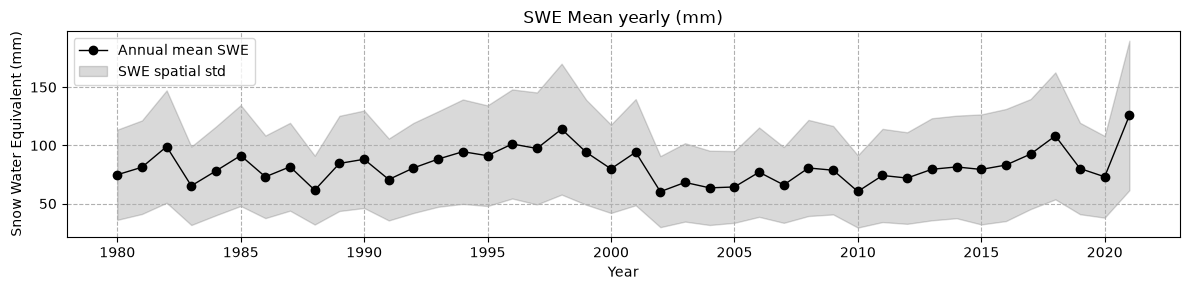

In [13]:
# plotting the time series of the yearly swe mean
fig = plt.figure(figsize=(12,3))

plt.plot(snow_sub_ts['time'], snow_sub_ts['swe_mean'], c='k', marker='o', linewidth=1, label='Annual mean SWE')
# and we can add the standard deviation std into the plot
plt.fill_between(
    snow_sub_ts['time'],
    snow_sub_ts['swe_mean'] - snow_sub_ts['swe_std'],
    snow_sub_ts['swe_mean'] + snow_sub_ts['swe_std'],
    color='k', alpha=0.15, label='SWE spatial std'
)
# Add the legend
plt.legend()
# Add a grid 
plt.grid(True, which='both',linestyle='--')
# Add a title and axis labels
plt.title('SWE Mean yearly (mm)')
plt.ylabel('Snow Water Equivalent (mm)')
plt.xlabel('Year')
# plt.xlim([datetime(2014,1,1), datetime(2016,1,1)]) # if you want to set limits on the x-axis, you can define the dates of the limits here
plt.show()

# 🛰️ CCI Sea Ice 

Next, we will look at the data from [**CCI Sea Ice**](https://climate.esa.int/en/projects/sea-ice/). The Sea Ice dataset has seperate data files for [**sea ice thickness**](https://climate.esa.int/media/documents/Sea_Ice_Thickness_Product_User_Guide_1.0.pdf) and [**sea ice concentration**](https://climate.esa.int/media/documents/Sea_Ice_Concentration_Product_User_Guide_1.1.pdf). 

You can see the different data types when executing the command `list_ecv_datasets("SEAICE")` below. *siconc* is short for sea ice concentration, *sithick* is short for sea ice thickness. We will start with a file for the sea ice concentration. As above, we first define the data id and have a look at the structure of the data. 


## Sea Ice Concentration

In [14]:
# list_ecv_datasets("SEAICE")

In [15]:
cci_store = new_data_store('esa-cci-zarr')
siconc_id = 'ESACCI-SEAICE-L4-SICONC-AMSR_50.0kmEASE2-NH-2002-2017-fv2.1.zarr'
cci_store.describe_data(siconc_id)

#### What do we learn from the details?

When we look at the `bbox`, we see that it ranges from -5400 to +5400 and the dimensions are given in `xc` and `yc` rather than latitude and longitude. 


In [16]:
variables = ['ice_conc']
siconc_ds, siconc_name = open_data(siconc_id,var_names = variables)
siconc_ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 5137, yc: 216, xc: 216, nv: 2)
Coordinates:
  * time       (time) datetime64[ns] 41kB 2002-06-01T12:00:00 ... 2017-05-15T...
  * yc         (yc) float64 2kB 5.375e+03 5.325e+03 ... -5.325e+03 -5.375e+03
  * xc         (xc) float64 2kB -5.375e+03 -5.325e+03 ... 5.325e+03 5.375e+03
    lat        (yc, xc) float32 187kB dask.array<chunksize=(216, 216), meta=np.ndarray>
    lon        (yc, xc) float32 187kB dask.array<chunksize=(216, 216), meta=np.ndarray>
    time_bnds  (time, nv) datetime64[ns] 82kB dask.array<chunksize=(160, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    ice_conc   (time, yc, xc) float64 2GB dask.array<chunksize=(160, 216, 216), meta=np.ndarray>
Attributes: (12/41)
    Conventions:               CF-1.6 ACDD-1.3
    Lambert_Azimuthal_Grid:    -2147483647
    algorithm:                 SICCI2VLF (6V, 37V, 37H)
    cdm_data_type:             Grid
    contributor_name:          Leif Toudal Pedersen, Gorm Dybkjaer, Steinar E...
    contributor_role:          PrincipalInvestigator,author,author,author,aut...
    ...                        ...
    time_coverage_end:         19700101T000001
    time_coverage_resolution:  P1D
    time_coverage_start:       19700101T000001
    title:                     Sea Ice Concentration Climate Data Record from...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    tracking_id:               19fbb910-dd02-4b1f-a078-a69ed3883d4b

Let's create a first simple plot with the toolbox to see how the data looks like. 

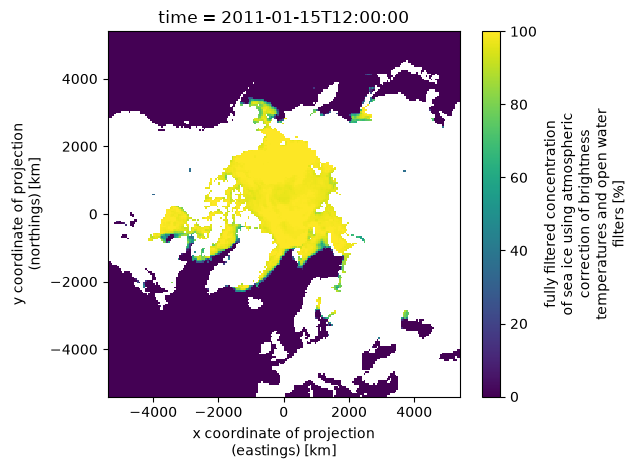

In [17]:
# get the plotting operator
plot_op = get_op('plot')

# Create a plot with the toolbox
plot_op(
    ds=siconc_ds,  # Dataset variable
    var='ice_conc',       # Variable you want to plot
    indexers={'time': '2011-01-15'},  # Specify the date
    properties="cmap='viridis'",  # Pass other properties here, such as color
)

We see that the coordinates are given in km. If we would like to plot it as latitude and longitude on a map, we have to convert the coordinates to lat and lon. An example of how to do this is shown below. 

In [18]:
# Converting the km to latitude and longitude: 
# first, we get the coordinate arrays which are in km and convert to meters
xc = siconc_ds["xc"].values * 1000
yc = siconc_ds["yc"].values * 1000

# next, we build a 2D meshgrid since the projection is defined on a plane
xx, yy = np.meshgrid(xc, yc) # here we use the x and y in meters from above

# as transformer, we use the source EPSG:6931 (EASE-Grid 2.0 North), and our target is EPSG:4326 (lat/lon)
transformer = Transformer.from_crs("EPSG:6931", "EPSG:4326", always_xy=True)

# now we apply the transformer function to transform the x and y to latitude and longitude
lon, lat = transformer.transform(xx, yy)

# and lastly, we attach the lat and lon back to the dataset with assign_coords
siconc_ds = siconc_ds.assign_coords(
    lon=(("yc", "xc"), lon),
    lat=(("yc", "xc"), lat)
)

Now we can plot the data with cartopy to draw the outlines of the coasts. 

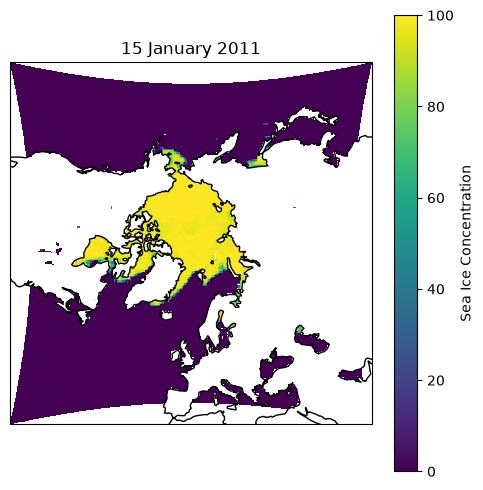

In [19]:
timestep = '2011-01-15'
iceconc = siconc_ds["ice_conc"].sel(time = timestep,method = 'nearest')
time_str = siconc_ds['time'].sel(time = timestep,method = 'nearest').dt.strftime('%d %B %Y').item()

fig = plt.figure(figsize=(5, 5))
# since we now have the latitude and longitude, we can use the north polar projection
ax = plt.axes(projection=ccrs.NorthPolarStereo())

iceconc.plot(
    ax=ax,
    x="lon", y="lat", # and here we tell the plotting command explicitly to use lat and lon for the x- and y-axes
    transform=ccrs.PlateCarree(),  
    cbar_kwargs={"label": "Sea Ice Concentration"}
)
ax.coastlines()
ax.set_title(time_str)
plt.tight_layout()
plt.show()

As the data is based on x and y dimension rather than latitude and longitude, we cannot use the toolbox to build a spatial subset. 

Instead, we can build a mask to cut out a specific area, e.g. the region between Greenland and Svalbard.

In [20]:
# here, we define a box from Svalbard to Greenland
lon_min, lat_min, lon_max, lat_max = -40, 70, 35, 82  

# now we can use the coordinates to build a mask
mask = (
    (siconc_ds["lon"] >= lon_min) & (siconc_ds["lon"] <= lon_max) &
    (siconc_ds["lat"] >= lat_min) & (siconc_ds["lat"] <= lat_max)
)

# and apply the mask
svalbard_greenland_ds = siconc_ds.where(mask, drop=True)

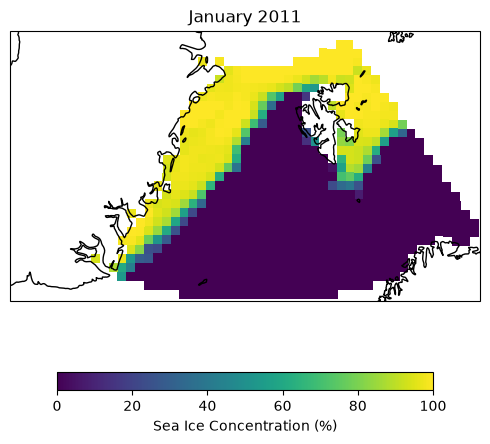

In [21]:
# and next, we can plot the masked dataset same as above. 
timestep = '2011-01-15'
iceconc = svalbard_greenland_ds["ice_conc"].sel(time = timestep,method = 'nearest')
time_str = svalbard_greenland_ds['time'].sel(time = timestep,method = 'nearest').dt.strftime('%B %Y').item()

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

iceconc.plot(
    ax=ax,
    x="lon", y="lat",
    transform=ccrs.PlateCarree(),  
    cbar_kwargs={"label": "Sea Ice Concentration (%)",
                "shrink": 0.8,
                "orientation": "horizontal"}
)
ax.coastlines()
ax.set_title(time_str)
plt.tight_layout()
plt.show()

Now, we can once again calculate the time series of the data. We will use the newly defined area, i.e. the masked dataset. 

In [22]:
# Getting the time-series mean operator
ts_mean_op = get_op('tseries_mean')
# Apply the operation to our dataset , specifying the variable of interest
siconc_ts_m = ts_mean_op(
    ds=svalbard_greenland_ds,
    var='ice_conc'    
).compute()

And this time, we can add a moving averate of the daily data. We could either use a window of 5-30 days to smoothen out variations, or we look at 365 days to see if the sea ice concentration increased or decreased over the years. 

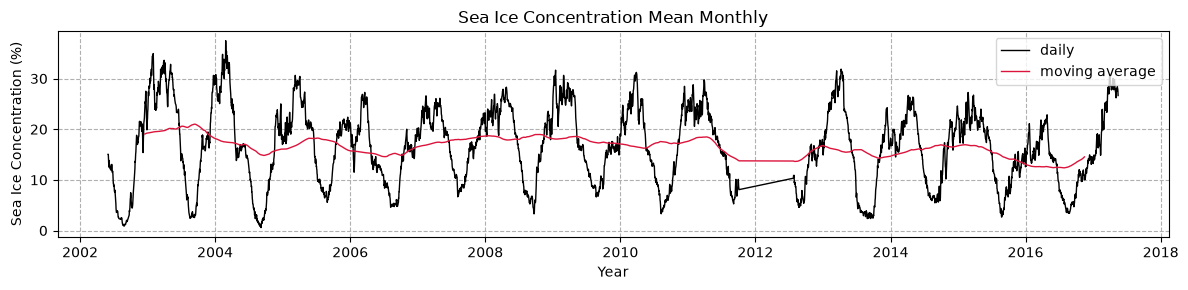

In [23]:
# calculate the rolling mean of the sea ice concentration: 
smooth_iceconc_avg = siconc_ts_m.ice_conc_mean.rolling(time=365, center=True).mean()  


fig = plt.figure(figsize=(12,3))
(siconc_ts_m.ice_conc_mean).plot(c='k',linewidth=1,label='daily')
(smooth_iceconc_avg).plot(c='crimson',linewidth=1,label='moving average') # plotting the moving average

# Add the legend
plt.legend()
# Add a grid so we can see the trend more easily
plt.grid(True, which='both',linestyle='--')
# Add a title and axis labels
plt.title('Sea Ice Concentration Mean Monthly')
plt.ylabel('Sea Ice Concentration (%)')
plt.xlabel('Year')
# plt.xlim([datetime(2014,1,1), datetime(2016,1,1)])
plt.show()

## Sea Ice Thickness
### 👉 Your turn!
#### Load and visualise the sea ice thickness and its mean.

➡️ ***Exercise 1: Load the sea ice thickness dataset `ESACCI-SEAICE-L3C-SITHICK-SIRAL_CRYOSAT2-NH25KMEASE2-2010-2017-fv2.0.zarr`, build a spatial subset as shown above and calculate the mean and moving average. Has the sea ice thickness de- or increased?***

In [45]:
# list_ecv_datasets("SEAICE")

In [44]:
# type your code here: 
sithick_id = 'ESACCI-SEAICE-L3C-SITHICK-SIRAL_CRYOSAT2-NH25KMEASE2-2010-2017-fv2.0.zarr'


In [43]:
# Solution - loading the dataset, building a spatial subset:
sithick_id = 'ESACCI-SEAICE-L3C-SITHICK-SIRAL_CRYOSAT2-NH25KMEASE2-2010-2017-fv2.0.zarr'

variables = ['sea_ice_thickness', 'sea_ice_concentration']
sithick_ds, sithick_name = open_data(sithick_id, var_names = variables)


# Get 1D coordinate arrays (km) and convert to meters
xc = sithick_ds["xc"].values * 1000
yc = sithick_ds["yc"].values * 1000

# Build 2D meshgrid since the projection is defined on a plane
xx, yy = np.meshgrid(xc, yc)

# Transformer: source CRS = EPSG:6931 (EASE-Grid 2.0 North), target = EPSG:4326 (lat/lon)
transformer = Transformer.from_crs("EPSG:6931", "EPSG:4326", always_xy=True)

lon, lat = transformer.transform(xx, yy)

# Attach back to the dataset as 2D coordinates
sithick_ds = sithick_ds.assign_coords(
    lon=(("yc", "xc"), lon),
    lat=(("yc", "xc"), lat)
)


lon_min, lat_min, lon_max, lat_max = -40, 70, 35, 82  # box from Svalbard to Greenland

mask = (
    (sithick_ds["lon"] >= lon_min) & (sithick_ds["lon"] <= lon_max) &
    (sithick_ds["lat"] >= lat_min) & (sithick_ds["lat"] <= lat_max)
)

sithick_sval_gl = sithick_ds.where(mask, drop=True)

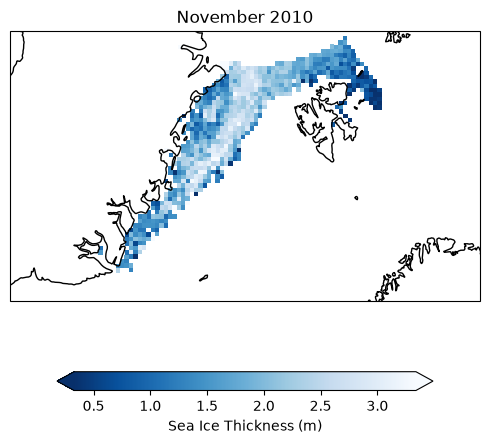

In [50]:
# Solution - visualise the sea ice thickness as a map

timestep = "2010-11-01"
icethick = sithick_sval_gl["sea_ice_thickness"].sel(time = timestep,method = 'nearest')
time_str = sithick_sval_gl['time'].sel(time = timestep,method = 'nearest').dt.strftime('%B %Y').item()

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

icethick.plot(
    ax=ax,
    x="lon", y="lat",
    transform=ccrs.PlateCarree(),  
    cmap="Blues_r",
    robust=True,
    cbar_kwargs={"label": "Sea Ice Thickness (m)",
                "shrink": 0.8,
                "orientation": "horizontal"}
)
ax.coastlines()
ax.set_title(time_str)
plt.tight_layout()
plt.show()

In [51]:
# Solution - calculate the mean accross the dataset to get the time series:
# Getting the time-series mean operator
ts_mean_op = get_op('tseries_mean')
# Apply the operation to our dataset , specifying the variable of interest
sithick_ts = ts_mean_op(
    ds=sithick_sval_gl,
    var='sea_ice_thickness'    
).compute()

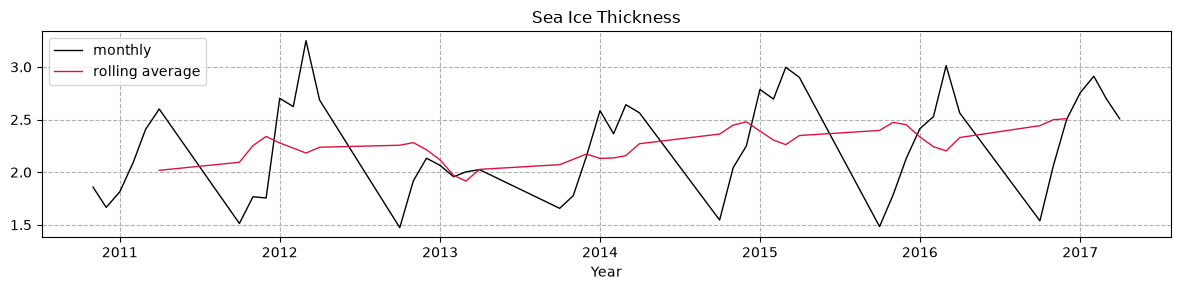

In [52]:
# Solution - plot the time series and the rolling mean of the sea ice thickness:
from datetime import datetime, timedelta

smooth_icethick_avg = sithick_ts.sea_ice_thickness_mean.rolling(time=10, center=True).mean()  

fig = plt.figure(figsize=(12,3))
(sithick_ts.sea_ice_thickness_mean).plot(c='k',linewidth=1,label='monthly')
(smooth_icethick_avg).plot(c='crimson',linewidth=1,label='rolling average')

# Add the legend
plt.legend()
# Add a grid 
plt.grid(True, which='both',linestyle='--')
# Add a title and axis labels
plt.title('Sea Ice Thickness')
plt.ylabel('')
plt.xlabel('Year')
plt.show()

# 🛰️ CCI Icesheets

The [CCI Ice Sheets](https://climate.esa.int/en/projects/ice-sheets-greenland/) data has a large variety of parameters and datasets which you can see when listing the data ids for SEAICE. The [Product User Guide](https://climate.esa.int/media/documents/DTU-ESA-GISCCI-PUG-001_v3.1.pdf) can help you to learn about the details of the parameters and datasets. 


Here are some abbreviations to guide you through the datasets:
Gravimetry Mass Balance (GMB), Gravity Recovery and Climate Experiment (GRACE), Ice Velocity (IV), multispectral imagery (MSI), Synthetic Aperture Radar (SAR), Surface Elevation Change (SEC)

➡️ ***Exercise 2: Load the ice sheet dataset for the surface elevation change `esacci.ICESHEETS.yr.Unspecified.SEC.multi-sensor.multi-platform.UNSPECIFIED.1-2.r1` and plot it as a map.***

In [27]:
# list_ecv_datasets('ICESHEETS')

In [54]:
# type your code here...

cci_store = new_data_store('esa-cci')
icesheet_id = 'esacci.ICESHEETS.yr.Unspecified.SEC.multi-sensor.multi-platform.UNSPECIFIED.1-2.r1'
# cci_store.describe_data(icesheet_id)

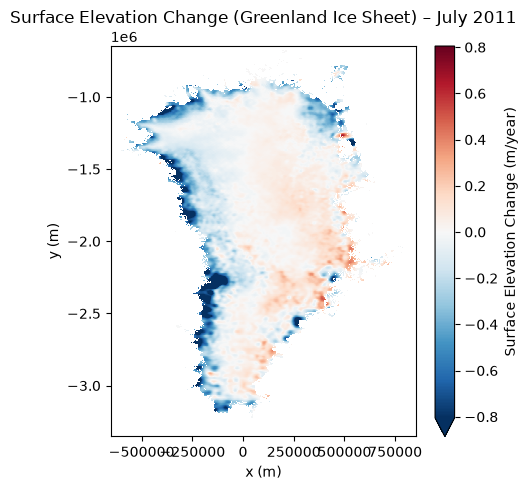

In [55]:
# Solution - opening the file and plotting a time step:

icesheet_id = 'esacci.ICESHEETS.yr.Unspecified.SEC.multi-sensor.multi-platform.UNSPECIFIED.1-2.r1'
cci_store = new_data_store('esa-cci')
cci_store.describe_data(icesheet_id)
timestep = '2011-07-01'
# open the dataset
variables = ['SEC']
icesheet_ds, icesheet_name = open_data(icesheet_id, var_names = variables)


# Extract the SEC data for the first time slice
sec = icesheet_ds["SEC"].sel(time=timestep, method = 'nearest')
time_str = icesheet_ds['time'].sel(time=timestep, method = 'nearest').dt.strftime('%B %Y').item()


# Plot the data
plt.figure(figsize=(5, 5))
sec.plot(
    cmap="RdBu_r",
    robust=True,
    cbar_kwargs={"label": "Surface Elevation Change (m/year)"}
)
plt.title("Surface Elevation Change (Greenland Ice Sheet) – " + time_str)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

➡️ **Exercise 3: Try to plot at a cross-section of the surface elevation change dataset along Greenland (e.g. along the x=0 m or y=2e6 m axis) to see the surface elevation across the ice sheet.**

In [ ]:
# type your code here...


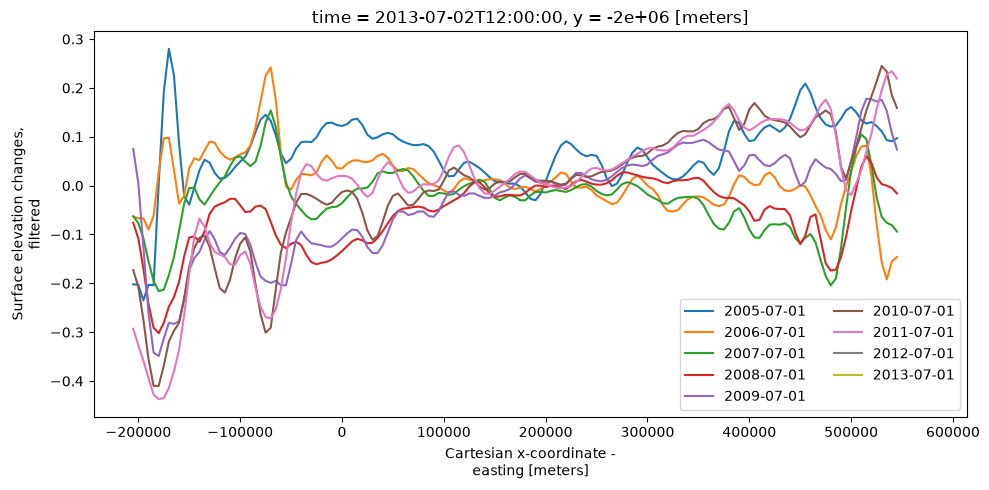

In [61]:
# Solution - plotting a cross-section of the surface elevation change:

# Here, we show you how you can plot multiple years with a loop, e.g. from 2004 to 2014:
# Define years to loop through
years = range(2005, 2014) 
# open a figure:
fig = plt.figure(figsize=(10,5))

# now we can loop through the years:
for year in years:
    # Create timestep from the years defined above, we will use the first of July, but with the method = "nearest", it will take the next available data 
    plot_date = f'{year}-07-01'
    icesheet_ds["SEC"].sel(time=plot_date,method='nearest').sel(y=-2e6, method='nearest').plot(label=plot_date)
plt.legend(ncol=2) # with ncol, you can create several columns for the legend

# 🛰️ CCI Cloud
Let's have a look at **uncertainties** in datasets. When retrieving parameters from satellite data, one encounters a variety of challenges. Some parameters are difficult to retrieve due to cloud cover, e.g. fires. For clouds on the other hand, it is difficult to distinguish between ice or snow covered surfaces and clouds. Additionally, depening on the season there might not be enough sunlight above the Arctic or Antarctic circles during their winter time. 
The CCI data always includes the uncertainties. A good example is the cloud data. We have a dedicated Jupyter Notebook on the uncertainties in the CCI Cloud data here: [Cloud Uncertainties](https://github.com/esa-cci/ect-training/blob/main/lps_vienna_06_2025/LPS_cloud_uncertainties.ipynb). 

➡️ **Exercise 4: Load the CCI CLOUD dataset `ESACCI-L3C_CLOUD-CLD_PRODUCTS-AVHRR_NOAA-1982-2016-fv3.0.zarr` and find out what the name of the uncertainty parameter is. Load the cloud uncertainties and plot them as a map. Do you have an idea why the uncertainty might be higher in some areas than others?**

In [29]:
# list_ecv_datasets("CLOUD") 

In [31]:
# type your code here...
cloud_id = 'ESACCI-L3C_CLOUD-CLD_PRODUCTS-AVHRR_NOAA-1982-2016-fv3.0.zarr'


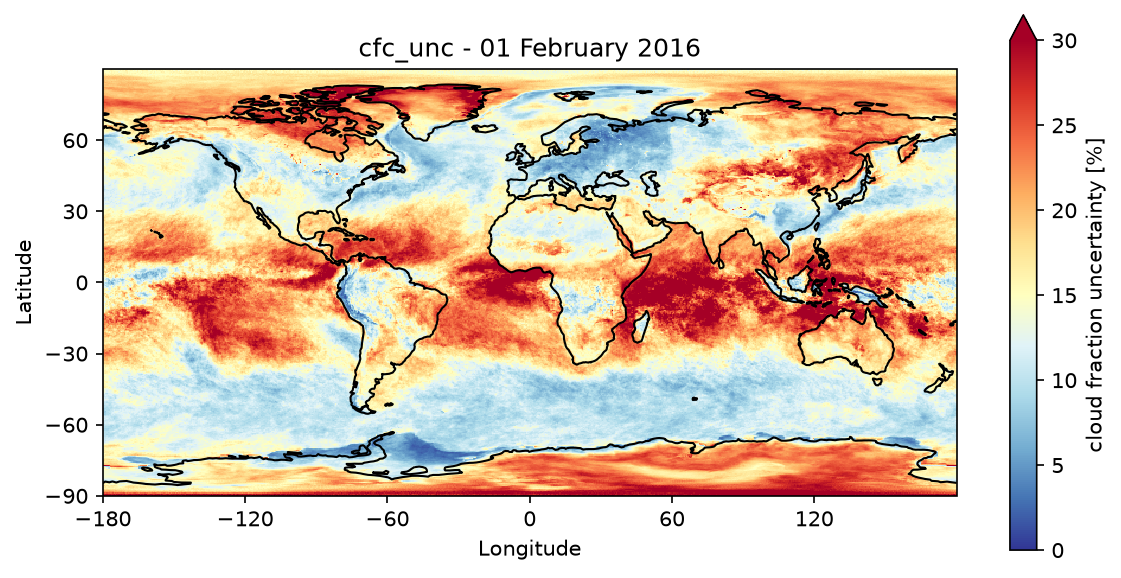

In [62]:
# Solution 

cci_store = new_data_store('esa-cci-zarr')
cloud_id = 'ESACCI-L3C_CLOUD-CLD_PRODUCTS-AVHRR_NOAA-1982-2016-fv3.0.zarr'
cci_store.describe_data(cloud_id)

# call the variable cfc_unc
variables =  ['cfc_unc']
cloud_ds,cloud_name = open_data(cloud_id, var_names = variables)

timestep = '2016-02-01'
# Get date for the title
time_str = cloud_ds['time'].sel(time=timestep,method='nearest').dt.strftime('%d %B %Y').item()

# increasing the resolution of the figure 
plt.rcParams['figure.dpi'] = 150  

# getting the plotting operator from the toolbox
plot_map = get_op('plot_map')

plot_map(
    cloud_ds.sel(time=timestep, method='nearest'), 
    var="cfc_unc",
    projection="PlateCarree", 
    title="cfc_unc - " + time_str,
    properties=dict(cmap="RdYlBu_r", 
                    xticks=np.arange(-180, 180, 60), 
                    yticks=np.arange(-90, 90, 30),
                    vmin=0, vmax=30
                    )
)
plt.gca().set_xlabel("Longitude")
plt.gca().set_ylabel("Latitude")
plt.show()